# Imports

In [1]:
import pandas as pd
import plotly.express as px
# import plotly.graph_objects as go
# from random import gauss
# from random import seed
# from pandas import Series
# from pandas.plotting import autocorrelation_plot
# from matplotlib import pyplot
# from plotly.subplots import make_subplots
# import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_squared_error
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot


# Data

In [2]:
airline_passengers_data_path = "https://storage.googleapis.com/edulabs-public-datasets/airline-passengers.csv"

In [3]:
df = pd.read_csv(airline_passengers_data_path)
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [4]:
df = pd.read_csv(airline_passengers_data_path, parse_dates=["Month"]).set_index("Month").squeeze()
df

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, Length: 144, dtype: int64

In [5]:
# prepare for prophet
df = pd.DataFrame(df).reset_index().rename(columns={"Month": "ds", "Passengers": "y"})

In [ ]:
df

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [42]:
px.line(df, x='ds', y='y', title='Monthly Airline Passengers')

# Prophet - technical details

In [43]:
model = Prophet(
    # a lot of params can appear here
)

In [44]:
model.fit(df)

13:04:54 - cmdstanpy - INFO - Chain [1] start processing
13:04:55 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
future = model.make_future_dataframe(50, freq='MS')

In [46]:
future

,ds
0,1949-01-01
1,1949-02-01
2,1949-03-01
3,1949-04-01
4,1949-05-01
...,...
189,1964-10-01
190,1964-11-01
191,1964-12-01
192,1965-01-01


In [47]:
forecast = model.predict(future)

In [48]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,107.773337,59.146079,115.715661,107.773337,107.773337,-21.389678,-21.389678,-21.389678,-21.389678,-21.389678,-21.389678,0.0,0.0,0.0,86.383658
1,1949-02-01,109.909203,49.534709,106.564703,109.909203,109.909203,-30.060193,-30.060193,-30.060193,-30.060193,-30.060193,-30.060193,0.0,0.0,0.0,79.849010
2,1949-03-01,111.838372,81.973595,141.892753,111.838372,111.838372,-0.500130,-0.500130,-0.500130,-0.500130,-0.500130,-0.500130,0.0,0.0,0.0,111.338242
3,1949-04-01,113.974238,81.412157,137.386710,113.974238,113.974238,-4.929875,-4.929875,-4.929875,-4.929875,-4.929875,-4.929875,0.0,0.0,0.0,109.044364
4,1949-05-01,116.041206,83.936171,140.503718,116.041206,116.041206,-3.624101,-3.624101,-3.624101,-3.624101,-3.624101,-3.624101,0.0,0.0,0.0,112.417105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,1964-10-01,626.251499,576.391494,631.180416,620.838465,631.227123,-21.428310,-21.428310,-21.428310,-21.428310,-21.428310,-21.428310,0.0,0.0,0.0,604.823190
190,1964-11-01,629.384548,540.435532,598.618623,623.754979,634.531307,-59.438040,-59.438040,-59.438040,-59.438040,-59.438040,-59.438040,0.0,0.0,0.0,569.946507
191,1964-12-01,632.416530,570.535848,628.880957,626.603468,637.804234,-33.326310,-33.326310,-33.326310,-33.326310,-33.326310,-33.326310,0.0,0.0,0.0,599.090220
192,1965-01-01,635.549579,585.289921,643.840787,629.520581,641.127621,-21.389678,-21.389678,-21.389678,-21.389678,-21.389678,-21.389678,0.0,0.0,0.0,614.159901


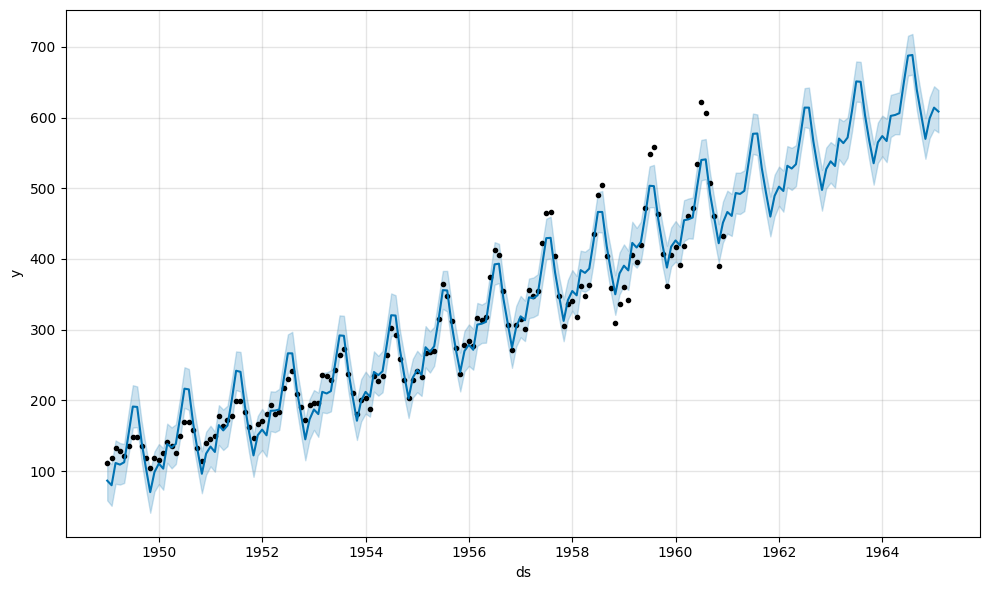

In [18]:
fig = model.plot(forecast)

# Evaluation

In [49]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    model,
    initial=f"{8*365} days",  # Training period (8 years)
    period=f"{6*30} days",   # Spacing between cutoffs (6 months)
    horizon=f"{2*365} days"   # Forecast horizon (2 years)
)


  0%|          | 0/4 [00:00<?, ?it/s]

13:05:04 - cmdstanpy - INFO - Chain [1] start processing
13:05:04 - cmdstanpy - INFO - Chain [1] done processing
13:05:04 - cmdstanpy - INFO - Chain [1] start processing
13:05:04 - cmdstanpy - INFO - Chain [1] done processing
13:05:04 - cmdstanpy - INFO - Chain [1] start processing
13:05:04 - cmdstanpy - INFO - Chain [1] done processing
13:05:04 - cmdstanpy - INFO - Chain [1] start processing
13:05:04 - cmdstanpy - INFO - Chain [1] done processing


In [50]:
df_cv['cutoff'].unique()

<DatetimeArray>
['1957-06-10 00:00:00', '1957-12-07 00:00:00', '1958-06-05 00:00:00',
 '1958-12-02 00:00:00']
Length: 4, dtype: datetime64[us]

### `performance_metrics`

The performance_metrics utility can be used to compute some useful statistics of the prediction performance, as a function of the distance from the cutoff (how far into the future the prediction was).

In [51]:
df_p = performance_metrics(df_cv, rolling_window=0.1)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,83 days,2060.011864,45.387354,43.623363,0.107387,0.116989,0.107324,0.000000
1,84 days,1909.408853,43.696783,42.028818,0.106681,0.110633,0.105166,0.000000
2,88 days,1815.662299,42.610589,39.842739,0.099650,0.110633,0.098540,0.111111
3,89 days,1630.751527,40.382565,36.501811,0.093445,0.110633,0.091842,0.222222
4,113 days,1537.997018,39.217305,34.101425,0.086875,0.110633,0.085613,0.333333
...,...,...,...,...,...,...,...,...
83,700 days,869.384235,29.485322,26.062772,0.063691,0.051078,0.061575,0.444444
84,721 days,801.182586,28.305169,24.036517,0.059831,0.038337,0.057581,0.555556
85,724 days,809.082549,28.444376,24.143209,0.059866,0.038337,0.057613,0.555556
86,727 days,869.327390,29.484358,24.928472,0.059059,0.038337,0.057551,0.555556


In [52]:
df_p['horizon'] = df_p['horizon'].astype(str)
px.line(df_p, x='horizon', y='mape')

In [54]:
df_p['mape'].mean()

np.float64(0.08422869397559617)

# Trend

##`growth`

<Axes: >

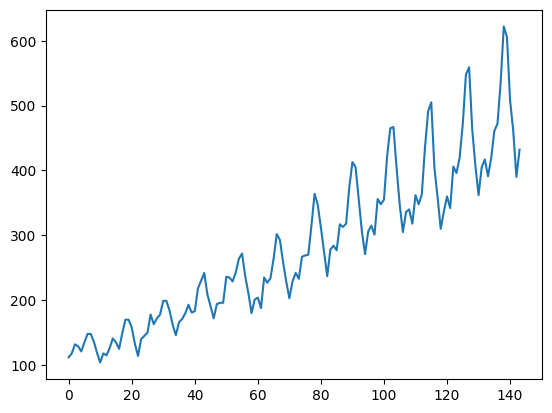

In [19]:
df['y'].plot()

<Axes: >

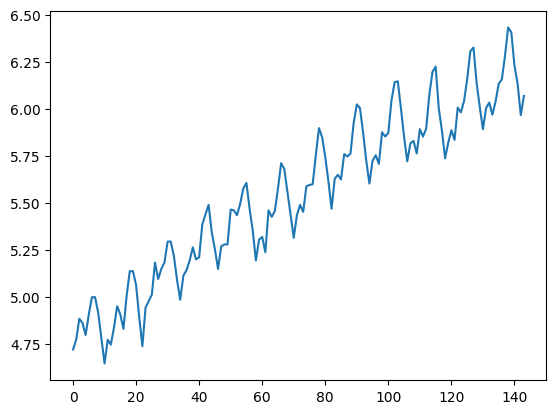

In [20]:
log_df = df.copy()
log_df['y'] = np.log(df['y'])
log_df['y'].plot()

12:35:41 - cmdstanpy - INFO - Chain [1] start processing
12:35:41 - cmdstanpy - INFO - Chain [1] done processing


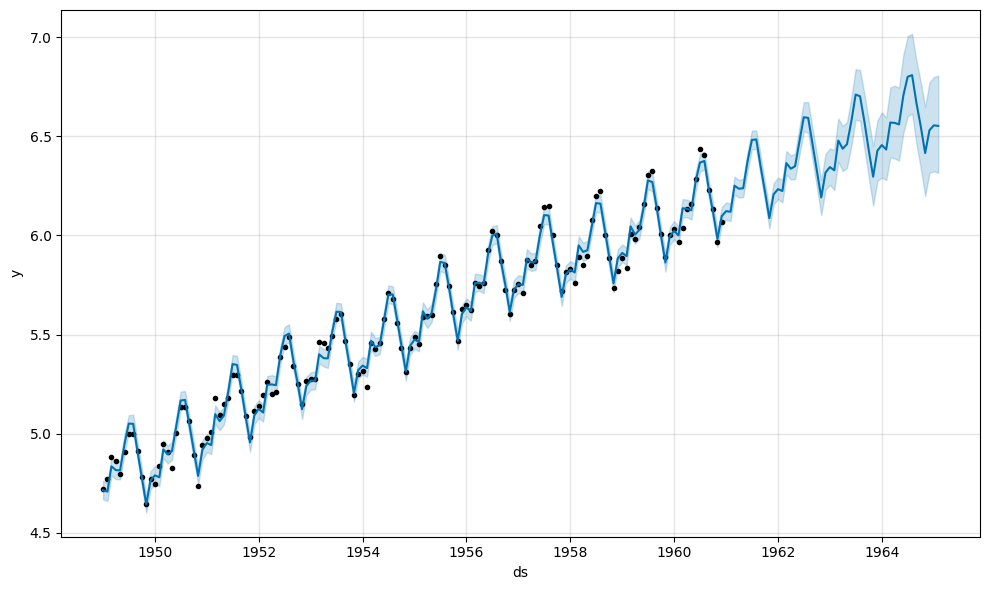

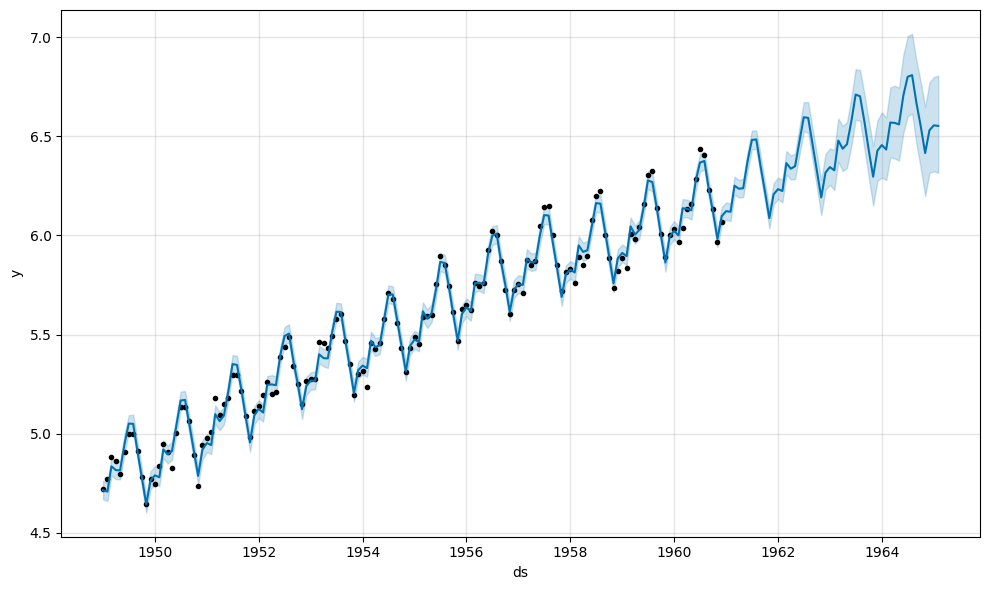

In [21]:
model = Prophet(
    growth='linear', # 'linear', 'logistic' or 'flat'
)

model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
model.plot(forecast)

12:36:07 - cmdstanpy - INFO - Chain [1] start processing
12:36:07 - cmdstanpy - INFO - Chain [1] done processing


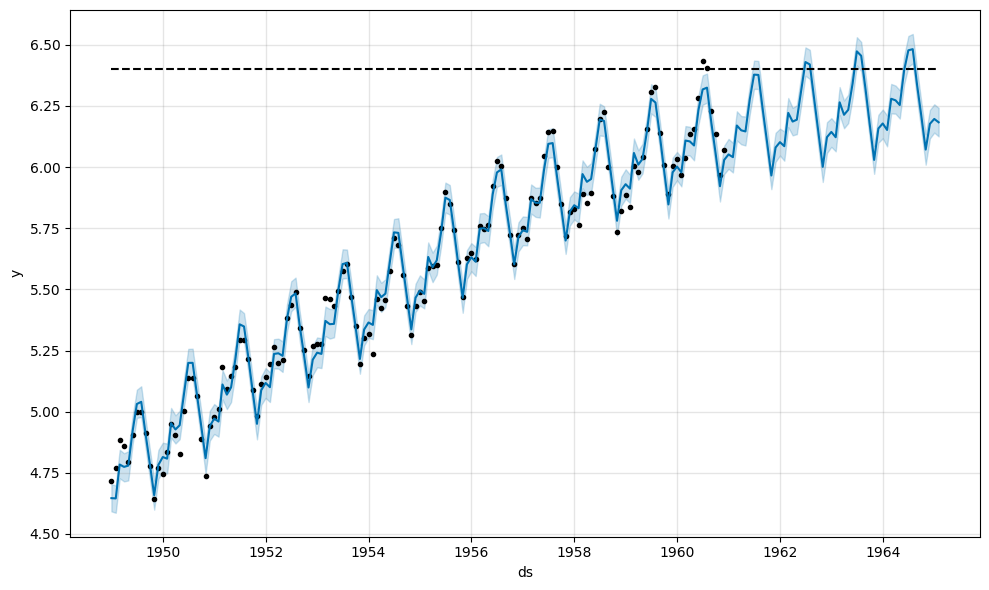

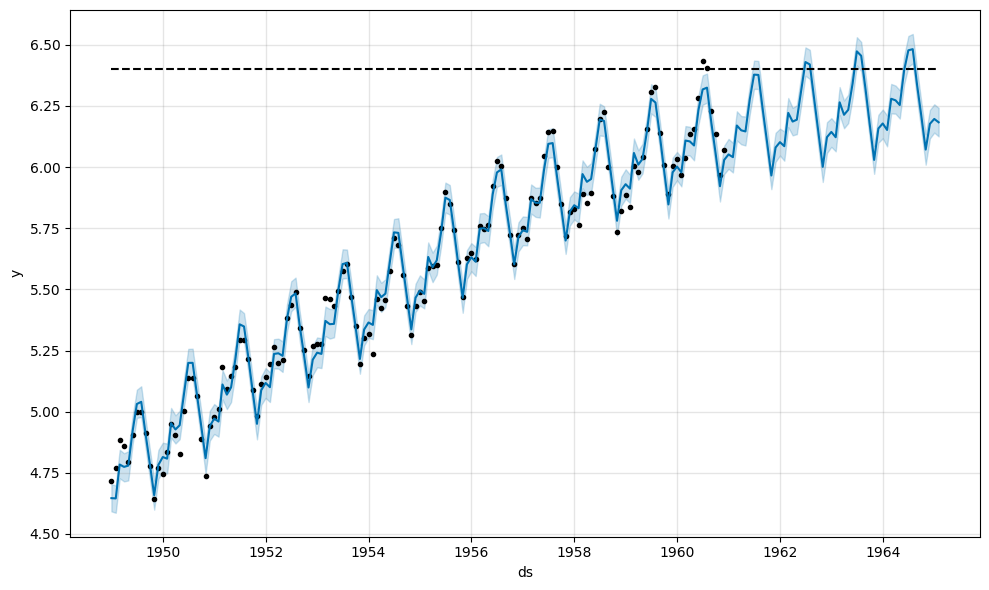

In [22]:
model = Prophet(
    growth='logistic', # 'linear', 'logistic' or 'flat'
)

log_df['cap'] = 6.4
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
future['cap'] = 6.4
forecast = model.predict(future)
model.plot(forecast)

# Hands-on

You are going to evaluate models according to the following parameters:
- initial training of 5 years
- cutoff periods of 2 years each
- horizon of 1 year
- use MAPE metric

1. Evaluate log_df model with linear trend
2. Evaluate log_df model with logistic trend
3. Which model performs better? Which one you should select?


# Changepoints

`n_changepoints`

`changepoint_prior_scale`

`changepoints`

<Axes: >

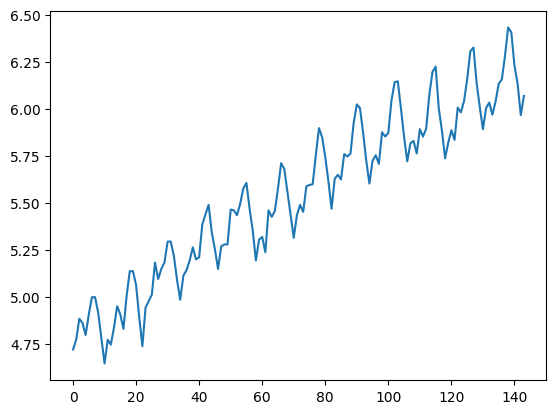

In [24]:
log_df['y'].plot()

In [25]:
model = Prophet()
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)

12:38:15 - cmdstanpy - INFO - Chain [1] start processing
12:38:15 - cmdstanpy - INFO - Chain [1] done processing


[[<matplotlib.lines.Line2D at 0x1180e1590>],

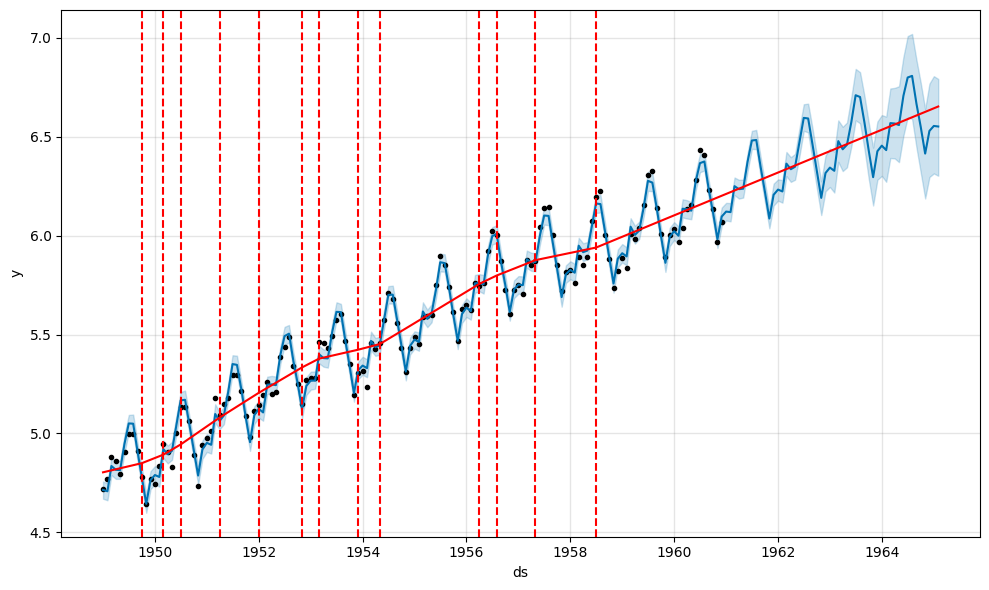

In [26]:

fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)

12:39:00 - cmdstanpy - INFO - Chain [1] start processing
12:39:00 - cmdstanpy - INFO - Chain [1] done processing


[[<matplotlib.lines.Line2D at 0x117b5b9d0>],

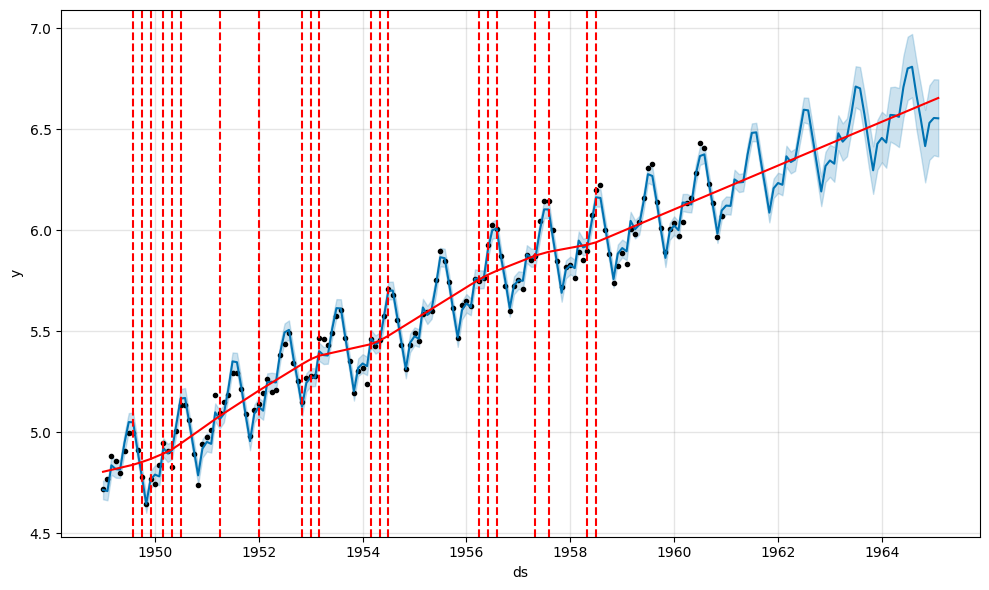

In [27]:
model = Prophet(
    n_changepoints=50
)
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)

## `changepoint_prior_scale`

12:39:18 - cmdstanpy - INFO - Chain [1] start processing
12:39:18 - cmdstanpy - INFO - Chain [1] done processing


[[<matplotlib.lines.Line2D at 0x1181c4e10>],

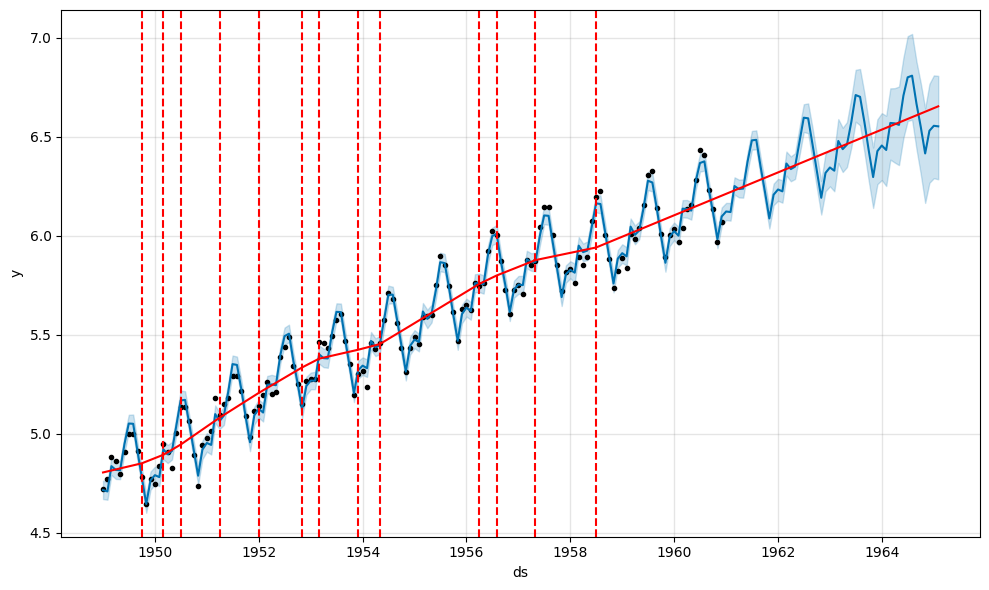

In [28]:
model = Prophet(
    # By default, this parameter is set to 0.05. Increasing it will make the trend more flexible
    changepoint_prior_scale=0.05
    # changepoint_prior_scale=0.1
    # changepoint_prior_scale=0.5
    # changepoint_prior_scale=0.001


)
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)

# Seasonality

## seasonality_mode

<Axes: >

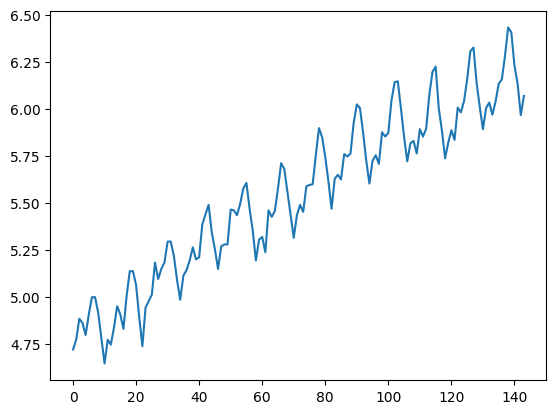

In [58]:
log_df['y'].plot()

13:17:06 - cmdstanpy - INFO - Chain [1] start processing
13:17:06 - cmdstanpy - INFO - Chain [1] done processing


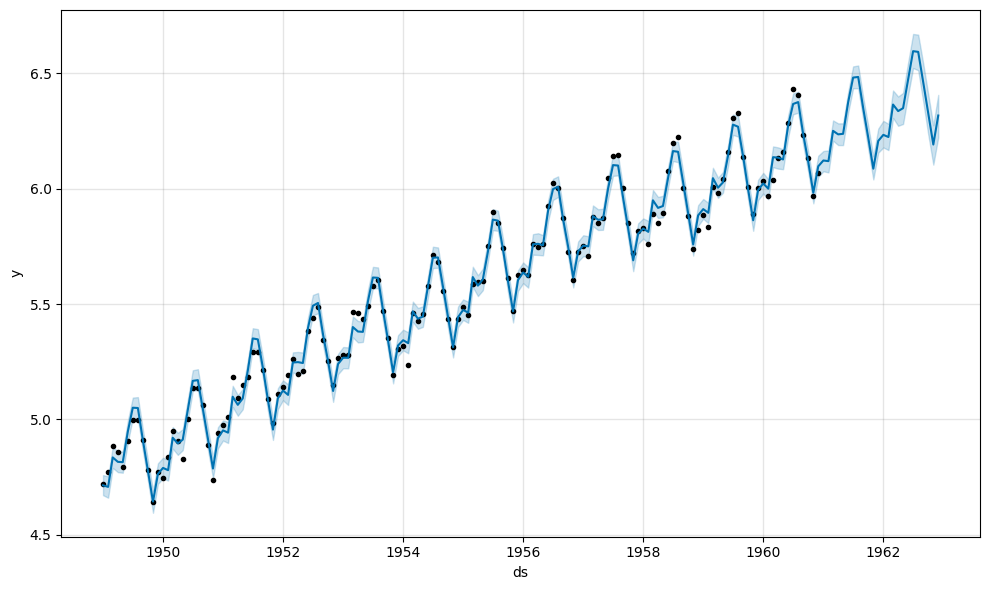

In [59]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    # seasonality_mode='multiplicative', # 'additive' (default) or 'multiplicative'
)
model.fit(log_df)
future = model.make_future_dataframe(24, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

13:17:11 - cmdstanpy - INFO - Chain [1] start processing
13:17:11 - cmdstanpy - INFO - Chain [1] done processing


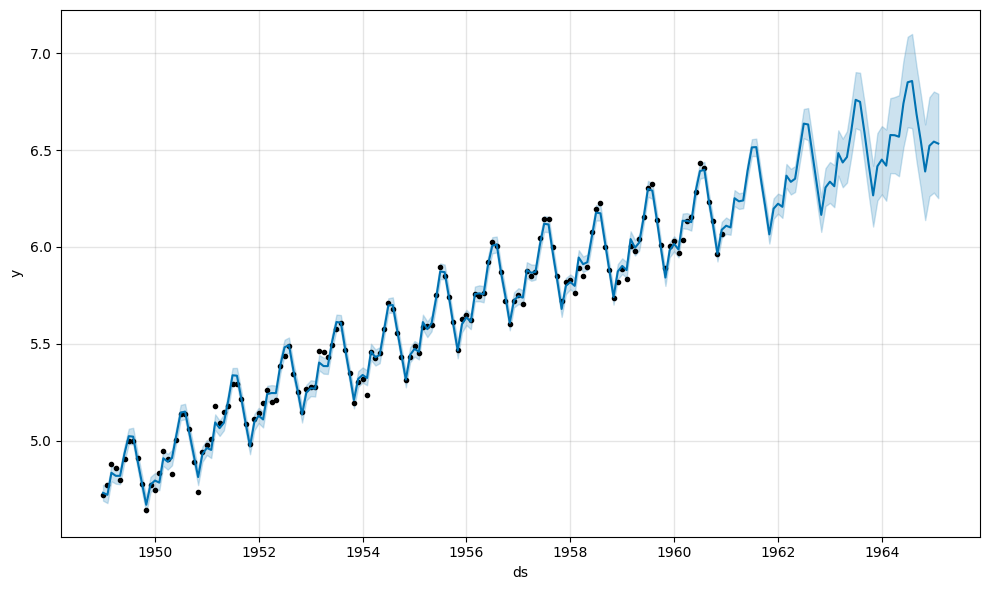

In [60]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative', # 'additive' (default) or 'multiplicative'
)
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

In [61]:
model.params

OrderedDict([('lp__', array([[673.47749]])),
             ('k', array([[0.08395527]])),
             ('m', array([[0.74813406]])),
             ('delta',
              array([[-1.3906940e-08,  1.1189142e-01,  1.1273749e-01,  3.6857209e-02,
                       1.4235061e-09, -5.3907658e-02, -1.3717629e-08, -6.1258454e-05,
                      -2.5674923e-08, -2.5978720e-03, -2.0607721e-01, -3.0323558e-09,
                       5.1217725e-02,  1.6536409e-01,  6.0775362e-05,  1.3824231e-09,
                       5.4995781e-09, -1.4389748e-02, -6.3732332e-02, -1.2720289e-02,
                      -4.5785507e-07, -1.1876332e-01, -8.4084215e-04,  1.3887529e-08,
                       1.1541491e-01]])),
             ('sigma_obs', array([[0.00488217]])),
             ('beta',
              array([[ 0.00468778, -0.02686006, -0.00242415,  0.01821102, -0.00526492,
                      -0.00426455, -0.00291705, -0.00151943,  0.00367853, -0.00826207,
                      -0.02075784, -0.002

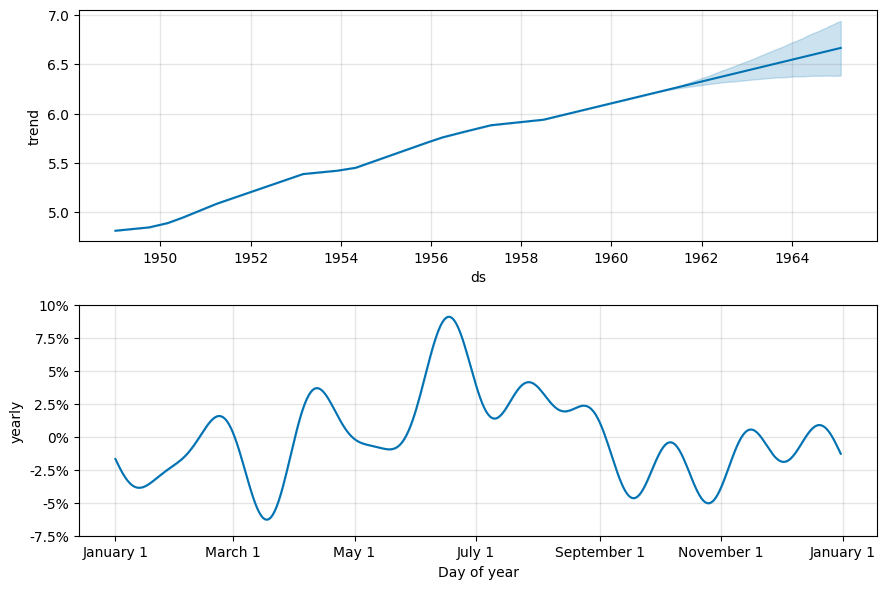

In [62]:
fig = model.plot_components(forecast)

## How Fourier order affects Prophet seasonality

In Prophet, `fourier_order` controls the flexibility of a seasonal component by setting how many sine/cosine basis terms are used.

- Lower `fourier_order` = smoother seasonality
- Higher `fourier_order` = more wiggles and more ability to fit complex seasonal shapes

### Why it matters
Prophet represents seasonality as a truncated Fourier series:
- each order adds one sine and one cosine term
- so `fourier_order=5` gives 10 basis functions
- `fourier_order=20` gives 40 basis functions

### Practical effect
- `fourier_order` too low → underfit seasonal pattern, missing important variation
- `fourier_order` too high → overfit noise, especially if the pattern is weak or data is short

### Typical guidance
- yearly seasonality often works with `fourier_order=10` (default)
- weekly seasonality can use `3` to `6`
- custom monthly seasonality may use `5` or so
- for very smooth, regular patterns choose smaller values
- for irregular or sharp seasonal changes choose larger values

So the Fourier order is essentially the seasonality complexity control knob: more order means more detail, less order means more smoothing.

13:21:28 - cmdstanpy - INFO - Chain [1] start processing
13:21:28 - cmdstanpy - INFO - Chain [1] done processing


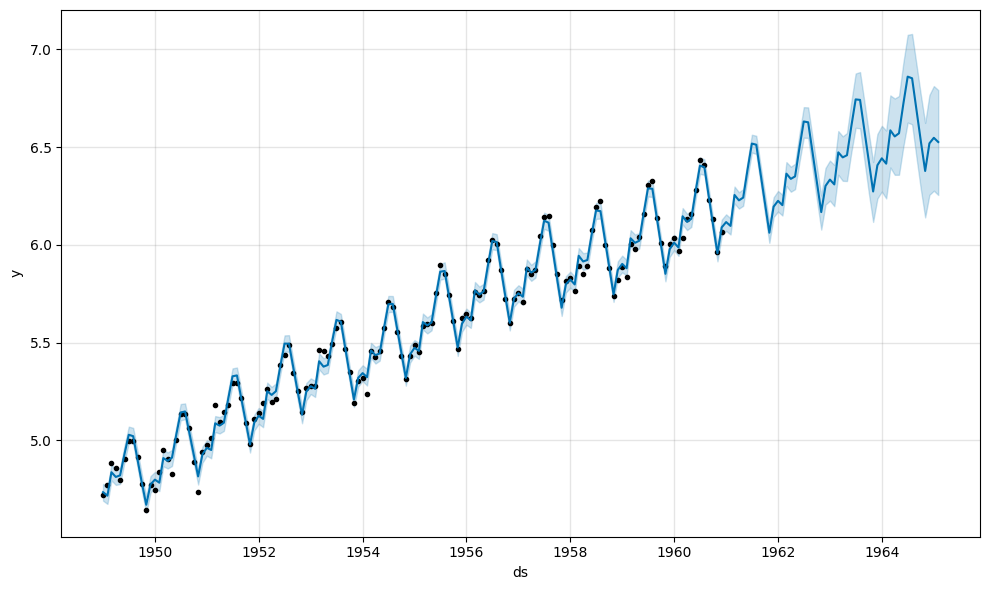

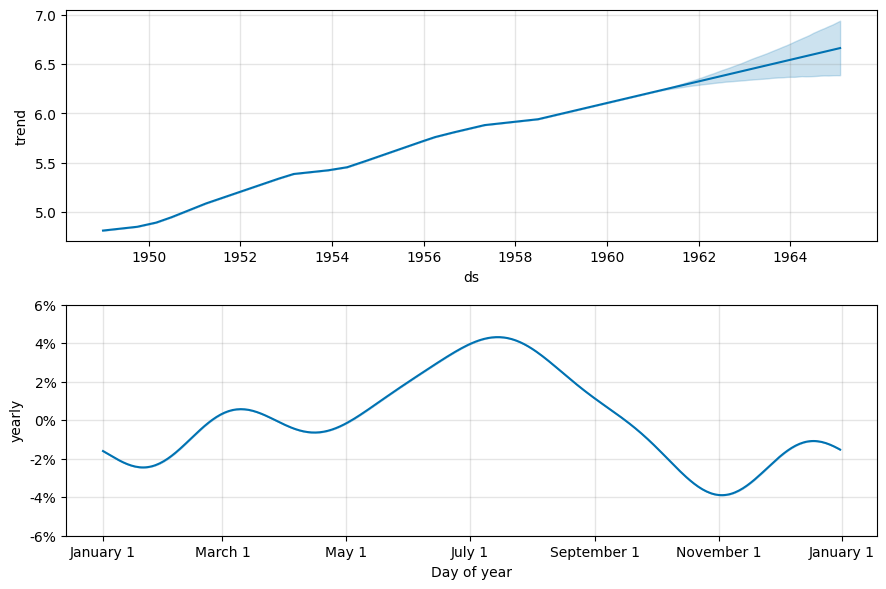

In [63]:
# fourier order
model = Prophet(
    # yearly_seasonality=True, # by default 10
    yearly_seasonality=5,
    # seasonality_prior_scale=0.01,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative', # 'additive' (default) or 'multiplicative'
)
model.fit(log_df)
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)
fig = model.plot_components(forecast)

## Hands-on
Use AI to learn about other seasonalities configurations.
Start from `seasonality_prior_scale`, learn how it affects the nodeling.
Try code snippets with different values to see how it affects the model.

##`seasonality_prior_scale`

## Custom seasonality

# Holidays

In [64]:
import holidays

il_holidays = holidays.IL(years=2025)
for date, name in sorted(il_holidays.items()):
    print(date, name)


2025-04-13 Pesach
2025-04-19 Seventh day of Pesach
2025-05-01 Independence Day (observed)
2025-06-02 Shavuot
2025-09-23 Rosh Hashanah
2025-09-24 Rosh Hashanah
2025-10-02 Yom Kippur
2025-10-07 Sukkot
2025-10-14 Simchat Torah / Shemini Atzeret


### built-in country holidays

In [65]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative', # 'additive' (default) or 'multiplicative'
)
model.add_country_holidays(country_name='US')
model.fit(log_df)




13:24:49 - cmdstanpy - INFO - Chain [1] start processing
13:24:49 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
model.train_holiday_names

,0
0,New Year's Day
1,Independence Day
2,Labor Day
3,Armistice Day
4,Thanksgiving Day
5,Christmas Day
6,Memorial Day
7,Washington's Birthday
8,Columbus Day
9,Independence Day (observed)


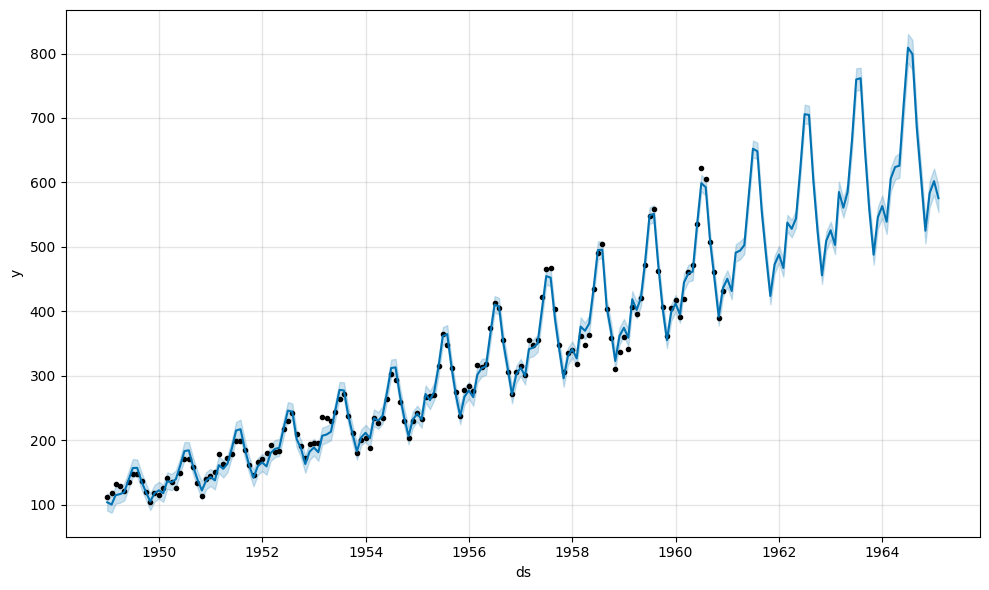

In [ ]:
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)

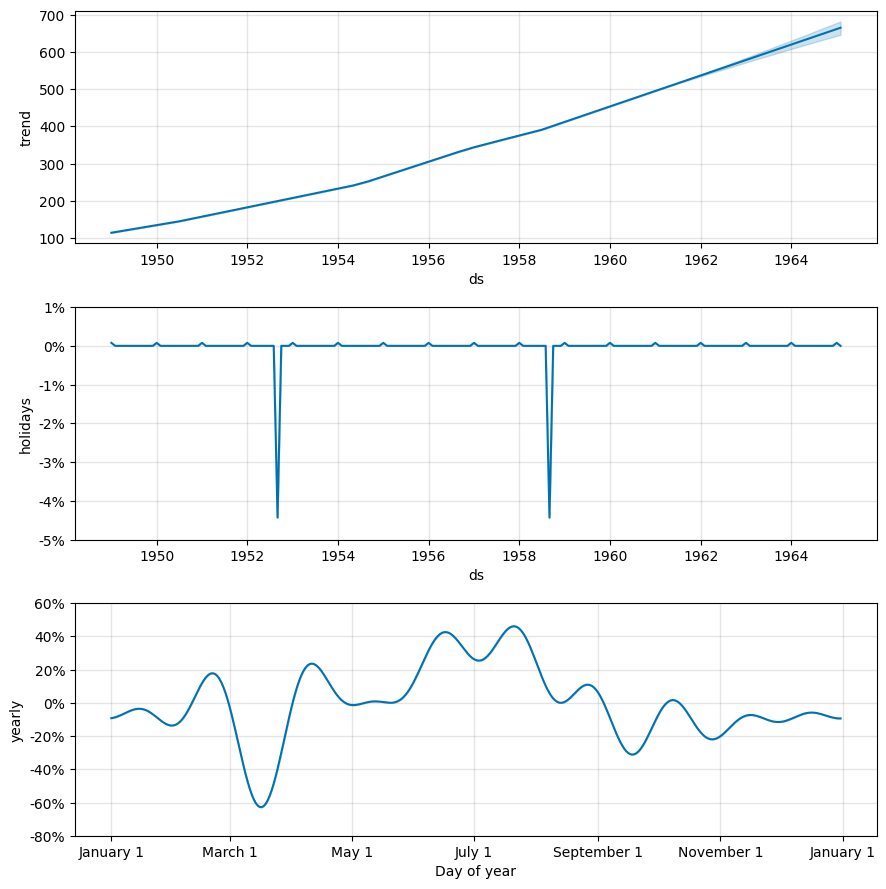

In [ ]:
fig = model.plot_components(forecast)

### custom holidays / special events

In [67]:
summer_olympics_dates = [
    # Helsinki 1952: July 19 – August 3
    '1952-07-19', '1952-07-20', '1952-07-21', '1952-07-22', '1952-07-23', '1952-07-24', '1952-07-25',
    '1952-07-26', '1952-07-27', '1952-07-28', '1952-07-29', '1952-07-30', '1952-07-31', '1952-08-01',
    '1952-08-02', '1952-08-03',

    # Melbourne 1956: November 22 – December 8
    '1956-11-22', '1956-11-23', '1956-11-24', '1956-11-25', '1956-11-26', '1956-11-27', '1956-11-28',
    '1956-11-29', '1956-11-30', '1956-12-01', '1956-12-02', '1956-12-03', '1956-12-04', '1956-12-05',
    '1956-12-06', '1956-12-07', '1956-12-08',

    # Rome 1960: August 25 – September 11
    '1960-08-25', '1960-08-26', '1960-08-27', '1960-08-28', '1960-08-29', '1960-08-30', '1960-08-31',
    '1960-09-01', '1960-09-02', '1960-09-03', '1960-09-04', '1960-09-05', '1960-09-06', '1960-09-07',
    '1960-09-08', '1960-09-09', '1960-09-10', '1960-09-11'
]
winter_olympics_dates = [
    # Oslo 1952: February 14 – February 25
    '1952-02-14', '1952-02-15', '1952-02-16', '1952-02-17', '1952-02-18', '1952-02-19',
    '1952-02-20', '1952-02-21', '1952-02-22', '1952-02-23', '1952-02-24', '1952-02-25',

    # Cortina d'Ampezzo 1956: January 26 – February 5
    '1956-01-26', '1956-01-27', '1956-01-28', '1956-01-29', '1956-01-30', '1956-01-31',
    '1956-02-01', '1956-02-02', '1956-02-03', '1956-02-04', '1956-02-05',

    # Squaw Valley 1960: February 18 – February 28
    '1960-02-18', '1960-02-19', '1960-02-20', '1960-02-21', '1960-02-22', '1960-02-23',
    '1960-02-24', '1960-02-25', '1960-02-26', '1960-02-27', '1960-02-28'
]

In [68]:
summer_olympics = pd.DataFrame({
  'holiday': 'summer-olympics',
  'ds': pd.to_datetime(summer_olympics_dates),
  'lower_window': 0,
  'upper_window': 1,
})
winter_olympics = pd.DataFrame({
  'holiday': 'winter-olympics',
  'ds': pd.to_datetime(winter_olympics_dates),
  'lower_window': 0,
  'upper_window': 1,
})
holidays = pd.concat((summer_olympics, winter_olympics))

In [69]:
holidays

,holiday,ds,lower_window,upper_window
0,summer-olympics,1952-07-19,0,1
1,summer-olympics,1952-07-20,0,1
2,summer-olympics,1952-07-21,0,1
3,summer-olympics,1952-07-22,0,1
4,summer-olympics,1952-07-23,0,1
...,...,...,...,...
29,winter-olympics,1960-02-24,0,1
30,winter-olympics,1960-02-25,0,1
31,winter-olympics,1960-02-26,0,1
32,winter-olympics,1960-02-27,0,1


In [70]:
model = Prophet(
    seasonality_mode='multiplicative',
    holidays=holidays
)
model.fit(log_df)

13:25:48 - cmdstanpy - INFO - Chain [1] start processing
13:25:48 - cmdstanpy - INFO - Chain [1] done processing


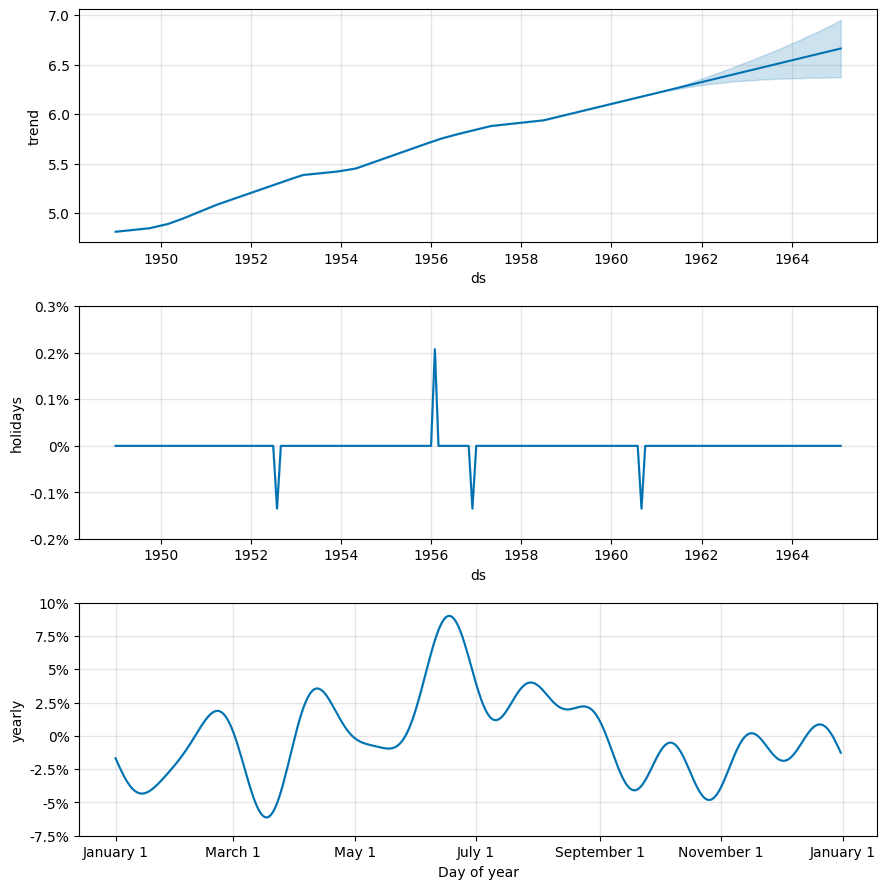

In [71]:
future = model.make_future_dataframe(50, freq='MS')
forecast = model.predict(future)
fig = model.plot_components(forecast)

In [ ]:
model.train_holiday_names

,0
0,summer-olympics
1,winter-olympics


# Tuning hyperparameters


Parameters that can be tuned

**changepoint_prior_scale**: This is probably the **most impactful parameter**. It determines the flexibility of the trend, and in particular how much the trend changes at the trend changepoints. If it is too small, the trend will be underfit and variance that should have been modeled with trend changes will instead end up being handled with the noise term. If it is too large, the trend will overfit and in the most extreme case you can end up with the trend capturing yearly seasonality. The **default of 0.05** works for many time series, but this could be tuned; a range of **[0.001, 0.5]** would likely be about right. Parameters like this (regularization penalties; this is effectively a lasso penalty) are often tuned on a log scale.

**seasonality_prior_scale**: This parameter controls the **flexibility of the seasonality**. Similarly, a large value allows the seasonality to fit large fluctuations, a small value shrinks the magnitude of the seasonality. The **default is 10**, which applies basically no regularization. That is because we very rarely see overfitting here (there’s inherent regularization with the fact that it is being modeled with a truncated Fourier series, so it’s essentially low-pass filtered). A reasonable range for tuning it would probably be **[0.01, 10]**; when set to 0.01 you should find that the magnitude of seasonality is forced to be very small. This likely also makes sense on a log scale, since it is effectively an L2 penalty like in ridge regression.

**holidays_prior_scale**: This controls flexibility to fit holiday effects. Similar to seasonality_prior_scale, it **defaults to 10** which applies basically no regularization, since we usually have multiple observations of holidays and can do a good job of estimating their effects. This could also be tuned on a range of **[0.01, 10]** as with seasonality_prior_scale.

**seasonality_mode**: Options are **['additive', 'multiplicative']**. **Default is 'additive'**, but many business time series will have multiplicative seasonality. This is best identified just from looking at the time series and seeing if the magnitude of seasonal fluctuations grows with the magnitude of the time series (see the documentation here on multiplicative seasonality), but when that isn’t possible, it could be tuned.

In [73]:

import itertools

param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 1.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
mapes = []  # Store the MAPEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(log_df)  # Fit model with given params
    df_cv = cross_validation(
        m,
        initial=f"{8*365} days",  # Training period (8 years)
        period=f"{3*30} days",   # Spacing between cutoffs (3 months)
        horizon=f"{2*365} days",   # Forecast horizon (2 years)
        parallel="processes"
    )
    df_p = performance_metrics(
        df_cv,
        rolling_window=0.1 # compute the metric across all simulated forecast points (not 10% as default)
    )
    mapes.append(df_p['mape'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['mape'] = mapes

13:30:28 - cmdstanpy - INFO - Chain [1] start processing
13:30:28 - cmdstanpy - INFO - Chain [1] done processing
13:30:30 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] done processing
13:30:31 - cmdstanpy - INFO - Chain [1] start processing
13:30:31 - cmdstanpy - INFO - Chain [1]

In [74]:
tuning_results.sort_values('mape', ascending=True)

,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,mape
17,0.50,10.00,multiplicative,0.005345
15,0.50,1.00,multiplicative,0.005356
13,0.50,0.01,multiplicative,0.005665
11,0.10,10.00,multiplicative,0.006359
9,0.10,1.00,multiplicative,0.006374
7,0.10,0.01,multiplicative,0.006453
14,0.50,1.00,additive,0.006469
16,0.50,10.00,additive,0.006470
12,0.50,0.01,additive,0.006772
5,0.01,10.00,multiplicative,0.008331
